In [1]:
#day1-2:区分不同数据类型，学会数据转化，构建注释表
import sys
import os

print(sys.executable)
print(os.getcwd())

/opt/anaconda3/envs/ai4s14/bin/python
/Volumes/LXH/ai4s_bootcamp


In [2]:
import numpy as np
import pandas as pd

In [3]:
genes = ["GeneA", "GeneB", "GeneC", "GeneD"]
cells = ["Cell1", "Cell2", "Cell3", "Cell4", "Cell5"]

print(genes)
print(type(genes))
print(cells)
print(type(cells))

['GeneA', 'GeneB', 'GeneC', 'GeneD']
<class 'list'>
['Cell1', 'Cell2', 'Cell3', 'Cell4', 'Cell5']
<class 'list'>


In [4]:
data_list = [
    [10, 2, 0, 5],
    [3, 0, 1, 8],
    [0, 6, 2, 1],
    [7, 3, 0, 0],
    [1, 9, 4, 2]
]#列表套列表，本质还是列表

print(data_list)
print(type(data_list))#list

[[10, 2, 0, 5], [3, 0, 1, 8], [0, 6, 2, 1], [7, 3, 0, 0], [1, 9, 4, 2]]
<class 'list'>


In [5]:
data_array = np.array(data_list)#把普通列表转化为numpy数组，因为数组更适合做矩阵计算
print(data_array)
print(type(data_array))#numpy.ndarray
print(data_array.shape)#5个基因4个细胞

[[10  2  0  5]
 [ 3  0  1  8]
 [ 0  6  2  1]
 [ 7  3  0  0]
 [ 1  9  4  2]]
<class 'numpy.ndarray'>
(5, 4)


In [6]:
expr_df = pd.DataFrame(data_array, index = cells,columns = genes)#把矩阵变成带标签的DataFrame，其同时保留了矩阵性和可读性，具有细胞和基因的注释
print(expr_df)
print(type(expr_df))#pandas.core.frame.DataFrame
print(expr_df.shape)

       GeneA  GeneB  GeneC  GeneD
Cell1     10      2      0      5
Cell2      3      0      1      8
Cell3      0      6      2      1
Cell4      7      3      0      0
Cell5      1      9      4      2
<class 'pandas.core.frame.DataFrame'>
(5, 4)


In [7]:
cell_sums = expr_df.sum(axis=1)#axis=1是计算行总数，axis=0是计算列总数
cell_sums

Cell1    17
Cell2    12
Cell3     9
Cell4    10
Cell5    16
dtype: int64

In [8]:
gene_sums = expr_df.sum(axis=0)
gene_sums

GeneA    21
GeneB    20
GeneC     7
GeneD    16
dtype: int64

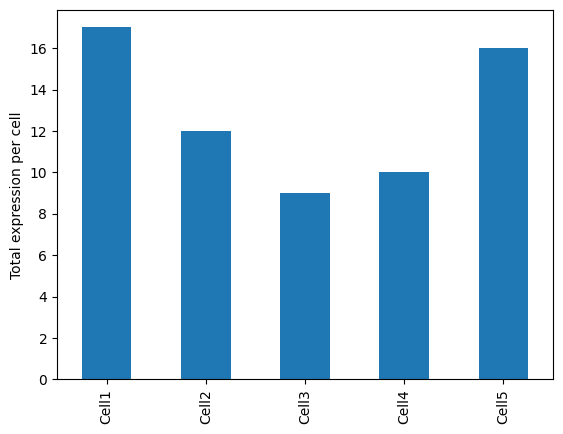

In [9]:
import matplotlib.pyplot as plt #导入python画图包

cell_sums.plot(kind = "bar")
plt.ylabel("Total expression per cell")
plt.show()

In [10]:
expr_df.head()#查看前几行数据

,GeneA,GeneB,GeneC,GeneD
Cell1,10,2,0,5
Cell2,3,0,1,8
Cell3,0,6,2,1
Cell4,7,3,0,0
Cell5,1,9,4,2


In [11]:
expr_df.index#查看行标签（细胞名）

Index(['Cell1', 'Cell2', 'Cell3', 'Cell4', 'Cell5'], dtype='object')

In [12]:
expr_df.columns#查看列标签（基因名）

Index(['GeneA', 'GeneB', 'GeneC', 'GeneD'], dtype='object')

In [13]:
expr_df["GeneA"]#取出 GeneA 这一整列，看某一个基因，在所有细胞里怎么表达

Cell1    10
Cell2     3
Cell3     0
Cell4     7
Cell5     1
Name: GeneA, dtype: int64

In [14]:
print(type(expr_df["GeneA"]))#pandas.core.series.Series

<class 'pandas.core.series.Series'>


In [15]:
expr_df.loc["Cell1"]#看某一个细胞，它的基因表达画像是什么

GeneA    10
GeneB     2
GeneC     0
GeneD     5
Name: Cell1, dtype: int64

In [16]:
expr_df.loc["Cell1", "GeneA"]#精准取出一个单元格的值

np.int64(10)

In [17]:
#构建一个细胞注释表，包含细胞类型和样本
cell_metadata = pd.DataFrame({"cell_type": ["NSC", "NSC", "Neuron", "Neuron", "Glia"],"sample": ["S1", "S1", "S1", "S2", "S2"]}, index=cells)

cell_metadata

,cell_type,sample
Cell1,NSC,S1
Cell2,NSC,S1
Cell3,Neuron,S1
Cell4,Neuron,S2
Cell5,Glia,S2


In [18]:
#day3：单细胞预处理 pipeline 入门：建立anndata对象，对原始表达矩阵进行归一化、对数变换

import scanpy as sc
print(sc.__version__)

1.11.5


/var/folders/q_/jss_6p6s64z8qt4bkf8rktwh0000gn/T/ipykernel_95808/327631429.py:4: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


In [19]:
adata = sc.AnnData(expr_df)
adata

AnnData object with n_obs × n_vars = 5 × 4

In [20]:
adata.X.sum(axis = 1)

array([17, 12,  9, 10, 16])

In [21]:
sc.pp.normalize_total(adata, target_sum = 1e4)#做归一化，把每个细胞的总表达量缩放到同一水平
adata.X.sum(axis = 1)

array([10000.   , 10000.   , 10000.   ,  9999.999, 10000.   ],
      dtype=float32)

In [22]:
sc.pp.log1p(adata)#对表达矩阵做 log(1 + x) 变换，log之后数值范围更平衡
adata.X

array([[8.679882 , 7.071124 , 0.       , 7.986905 ],
       [7.8244457, 0.       , 6.726633 , 8.805025 ],
       [0.       , 8.805025 , 7.7067127, 7.014015 ],
       [8.853808 , 8.0067005, 0.       , 0.       ],
       [6.4393506, 8.635154 , 7.8244457, 7.1316986]], dtype=float32)

In [23]:
sc.pp.pca(adata)

In [24]:
adata.obsm["X_pca"]

array([[-3.5656517 , -1.4735873 ,  3.688095  ],
       [ 2.88473   , -6.7482686 , -1.529167  ],
       [ 5.6478944 ,  4.7340164 , -0.05393109],
       [-7.5305085 ,  2.1265788 , -2.3045797 ],
       [ 2.5635338 ,  1.3612583 ,  0.19958116]], dtype=float32)

In [25]:
adata.obsm["X_pca"].shape

(5, 3)

In [26]:
sc.pp.neighbors(adata)#为每个细胞寻找“相似邻居”，构建细胞之间的关系图。

In [27]:
sc.tl.umap(adata)

In [28]:
adata.obsm["X_umap"]#读取 UMAP 坐标

array([[-1.7381307 , -0.30817574],
       [-3.1682694 , -0.1263064 ],
       [-1.3961095 ,  0.8775564 ],
       [-1.4887184 , -1.5307089 ],
       [-2.7722404 , -1.3531269 ]], dtype=float32)

In [29]:
adata.obsm["X_umap"].shape

(5, 2)

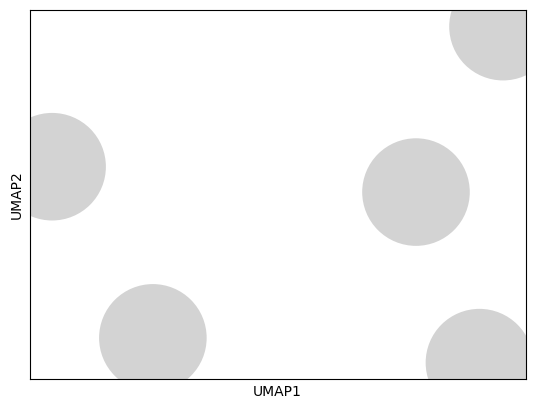

In [30]:
sc.pl.umap(adata)#画图，每个点代表一个细胞，点之间越近，通常表示表达模式越相似。

In [31]:
#在数据的观测值列表（obs）里，新增一个叫 cell_type 的列
adata.obs["cell_type"] = ["NSC", "NSC", "Neuron", "Neuron", "Glia"]
print(adata.obs.columns)

Index(['cell_type'], dtype='object')


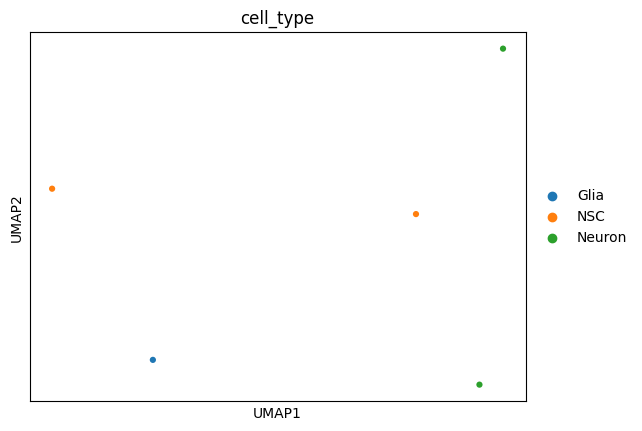

In [32]:
#画一张 UMAP 图，并按照 cell_type（细胞类型）这一列信息来给点上色
sc.pl.umap(adata, color = "cell_type", size = 80)

In [33]:
#day5:高变基因HVG筛选
sc.pp.highly_variable_genes(adata, n_top_genes=1, subset=False)#找出“在不同细胞之间变化最大”的基因
adata.var

,highly_variable,means,dispersions,dispersions_norm
GeneA,False,8.071678,8.021300,0.707107
GeneB,False,8.100048,7.802345,-0.707107
GeneC,True,7.014015,7.158298,1.000000
GeneD,True,7.781051,7.953300,1.000000


In [34]:
adata.var["highly_variable"]#显示并统计高变基因

GeneA    False
GeneB    False
GeneC     True
GeneD     True
Name: highly_variable, dtype: bool

In [35]:
adata.var[adata.var["highly_variable"]]#提取高变基因列中结果为true的

,highly_variable,means,dispersions,dispersions_norm
GeneC,True,7.014015,7.158298,1.0
GeneD,True,7.781051,7.953300,1.0


In [36]:
adata.var["highly_variable"].sum()#统计多少个是true的高变基因

np.int64(2)